In [1]:
# Cell 1: Setup
import re
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")
search_tool = TavilySearchResults(max_results=2)
from typing import TypedDict
from langgraph.graph import StateGraph, END

c:\Users\shiva\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\shiva\AppData\Local\Temp\ipykernel_20452\506327501.py:10: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=2)


In [2]:
# Cell 2: State
class State(TypedDict):
    messages: list
    next: str
    result: str
    steps_taken: list

In [3]:
# Cell 3: Workers
def add_agent(state: State) -> State:
    text = state["messages"][-1]
    nums = re.findall(r"\d+\.?\d*", text)
    result = str(float(nums[0]) + float(nums[1]))
    steps = state.get("steps_taken", []) + ["add"]
    return {"result": result, "steps_taken": steps, "messages": state["messages"]}

def multiply_agent(state: State) -> State:
    value = state.get("result") or state["messages"][-1]
    nums = re.findall(r"\d+\.?\d*", value)
    if len(nums) < 2:
        original_nums = re.findall(r"\d+\.?\d*", state["messages"][-1])
        result = str(float(nums[0]) * float(original_nums[-1]))
    else:
        result = str(float(nums[0]) * float(nums[1]))
    steps = state.get("steps_taken", []) + ["multiply"]
    return {"result": result, "steps_taken": steps, "messages": state["messages"]}

def web_search_agent(state: State) -> State:
    query = state["messages"][-1]
    results = search_tool.invoke(query)
    result = results[0]["content"] if results else "No results found."
    steps = state.get("steps_taken", []) + ["web_search"]
    return {"result": result, "steps_taken": steps, "messages": state["messages"]}

In [4]:
# Cell 4: Supervisor
def supervisor(state: State) -> State:
    steps_taken = state.get("steps_taken", [])
    prompt = f"""You are a supervisor routing tasks to workers in sequence.
Workers available:
- add: adds two numbers
- multiply: multiplies numbers (or doubles a result)
- web_search: searches the web
- END: task is fully complete

Current task: {state["messages"][-1]}
Steps already completed: {steps_taken}
Current result: {state.get("result", "none")}

Rules:
- For "add X and Y, then double the result": first route to add, then multiply, then END
- Never repeat a step that is already in steps_taken
- Reply with ONLY one word: add, multiply, web_search, or END"""

    response = llm.invoke(prompt)
    next_node = response.content.strip().lower()
    return {
        "next": next_node,
        "messages": state["messages"],
        "result": state.get("result", ""),
        "steps_taken": steps_taken,
    }

In [6]:
# Cell 5: Route function
def route(state: State) -> str:
    mapping = {
        "add": "add_agent",
        "multiply": "multiply_agent",
        "web_search": "web_search_agent",
    }
    return mapping.get(state["next"], END)

In [7]:
# Cell 6: Graph
builder = StateGraph(State)
builder.add_node("supervisor", supervisor)
builder.add_node("add_agent", add_agent)
builder.add_node("multiply_agent", multiply_agent)
builder.add_node("web_search_agent", web_search_agent)

builder.set_entry_point("supervisor")
builder.add_conditional_edges("supervisor", route, {
    "add_agent": "add_agent",
    "multiply_agent": "multiply_agent",
    "web_search_agent": "web_search_agent",
    END: END,
})
builder.add_edge("add_agent", "supervisor")
builder.add_edge("multiply_agent", "supervisor")
builder.add_edge("web_search_agent", "supervisor")

app = builder.compile()

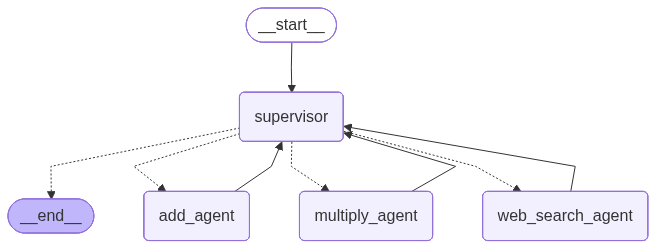

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
# Cell 7: Run
result = app.invoke({
    "messages": ["What is 8 multiplied by 3? and What is the purpose of MCP."],
    "next": "",
    "result": "",
    "steps_taken": [],
})
print("Steps taken:", result["steps_taken"])
print("Result:", result["result"])

Steps taken: ['multiply', 'web_search']
Result: So, what does this mean in practice? If you’re using an AI coding assistant like Cursor or Windsurf, MCP is the shared protocol that lets that assistant use external tools on your behalf. For example, with MCP an AI model could fetch information from a database, edit a design in Figma, or control a music app – all by sending natural-language instructions through a standardized interface. You (or the AI) no longer need to manually switch contexts or learn each tool’s API; the MCP “translator” bridges the gap between human language and software commands. [...] In final reflection, MCP represents a paradigm shift where AI is treated as a first-class user and operator of software. We’re moving toward a future where using a computer could mean telling an AI what outcome you want, and it figures out which apps to open and what buttons to press – a true personal developer/assistant. It’s a bit like having a superpower or at least a very competen